In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

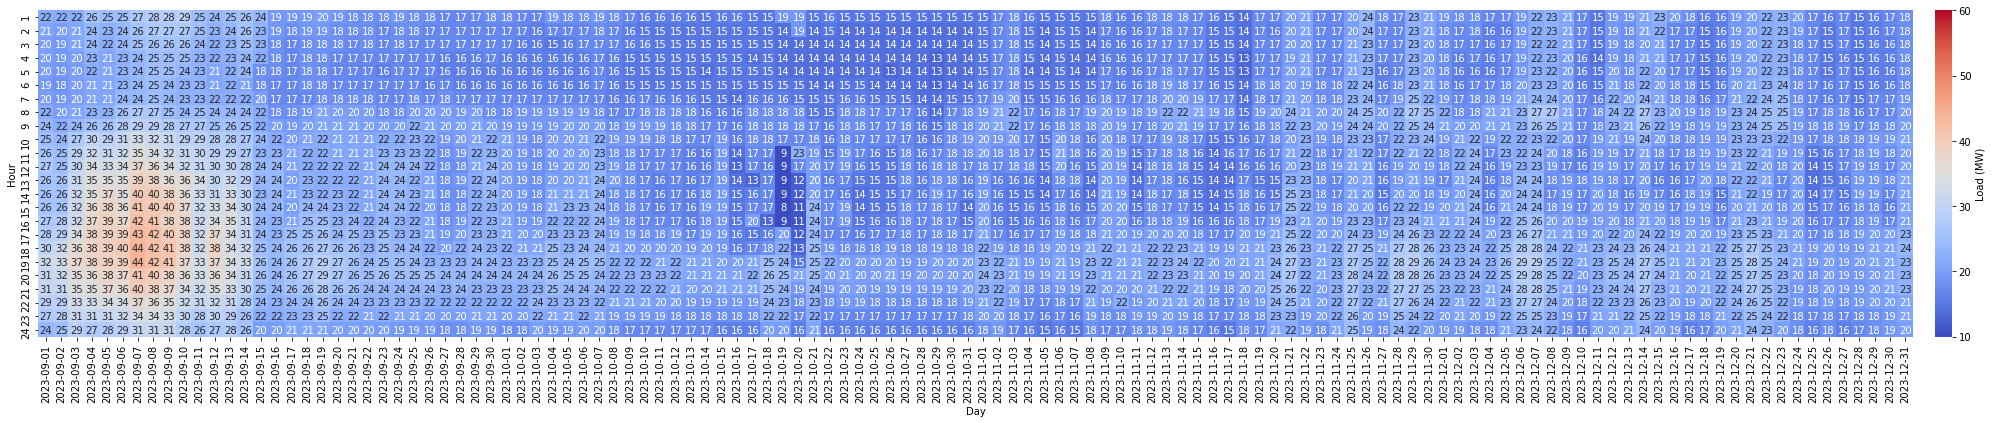

In [106]:
#month_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
month_list = ["09", "10", "11", "12"]
df = []
for mh in month_list:
    df_new = pd.read_csv("../data/nodalloadweights_4006_2023"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(40, 6))
sns.heatmap(hm_load, annot=True, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
# plt.title('Heatmap of Price (August)')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_fall_23.svg', format='svg')

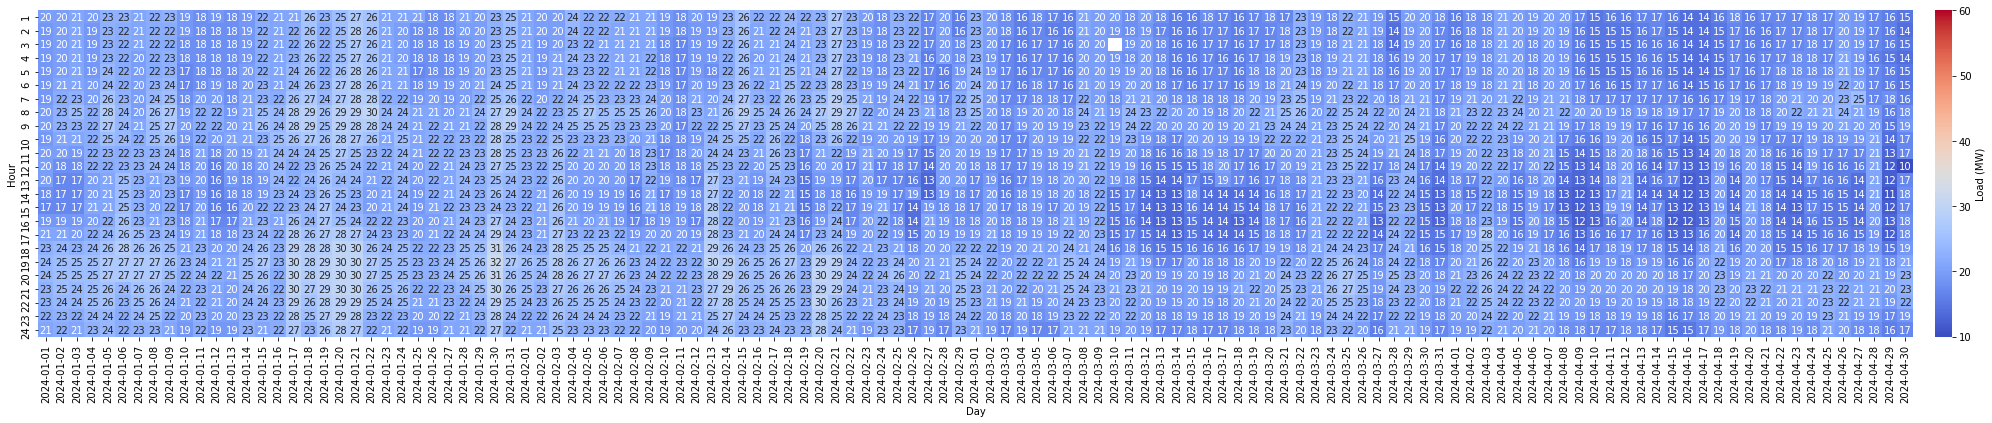

In [105]:
month_list = ["01", "02", "03", "04"]
df = []
for mh in month_list:
    df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(40, 6))
sns.heatmap(hm_load, annot=True, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_spring_24.svg', format='svg')

C:\Users\Dirk\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


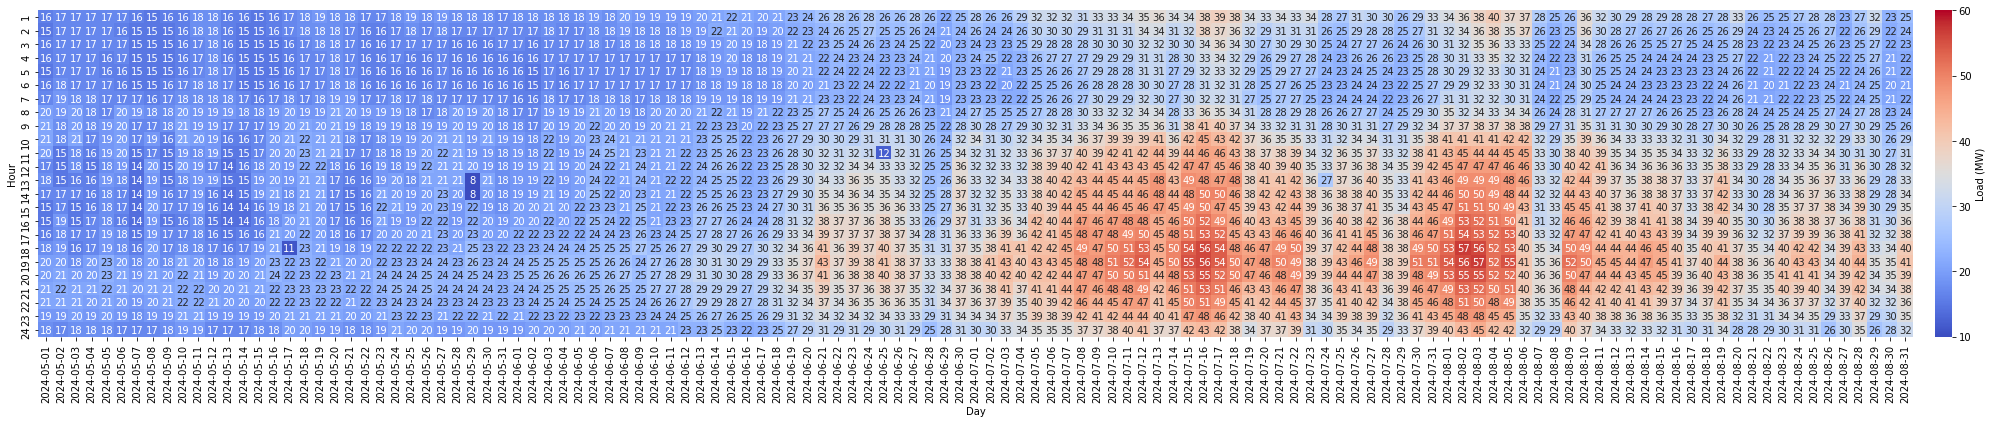

In [2]:
month_list = ["05", "06", "07", "08"]
df = []
for mh in month_list:
    if mh == "08":
        df_new = pd.read_csv("../data/toy.csv")
    else:
        df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(40, 6))
sns.heatmap(hm_load, annot=True, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
# plt.title('Heatmap of Price (August)')
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_summer_24.svg', format='svg')

In [3]:
# Data from 1 Sep 23 through 31 Aug 24
my_list = [["24", "01"], ["24", "02"], ["24", "03"], ["24", "04"], ["24", "05"], ["24", "06"], ["24", "07"], ["24", "08"], 
           ["23", "09"], ["23", "10"], ["23", "11"], ["23", "12"]]
df = []
for yr, mh in my_list:
    if [yr, mh] == ["24", "08"]:
        df_new = pd.read_csv("../data/toy.csv")
    else:
        df_new = pd.read_csv("../data/nodalloadweights_4006_20"+yr+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]

In [28]:
# Step 1: Calculate the total load per day and get the top N days
N = 5
top_days = (
    df.groupby('Day')['MW Factor']
    .max()
    .nlargest(N)
    .index
)

# Step 2: Filter the original DataFrame for these top N days
filtered_df = df[df['Day'].isin(top_days)]

# Step 3: Pivot the data
peak_days_df = filtered_df.pivot(index='Hour', columns='Day', values='MW Factor')

# Step 4: Add column with max value of each row
peak_days_df['Max'] = peak_days_df.max(axis = 1)

In [29]:
peak_days_df

Day,2024-07-15,2024-07-16,2024-08-02,2024-08-03,2024-08-05,Max
Hour,,,,,,
1,34.0,38.0,36.0,38.0,37.0,38.0
2,32.0,38.0,34.0,36.0,35.0,38.0
3,30.0,34.0,32.0,35.0,33.0,35.0
4,30.0,33.0,31.0,33.0,32.0,33.0
5,29.0,32.0,29.0,32.0,30.0,32.0
6,28.0,31.0,29.0,32.0,30.0,32.0
7,30.0,32.0,31.0,32.0,30.0,32.0
8,33.0,36.0,32.0,34.0,34.0,36.0
9,38.0,41.0,37.0,38.0,38.0,41.0


<AxesSubplot:xlabel='Hour'>

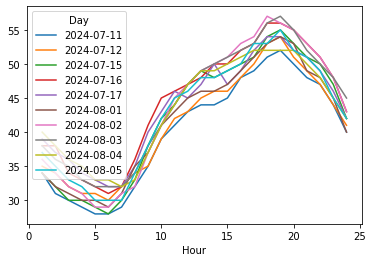

In [21]:
peak_days_df.plot()

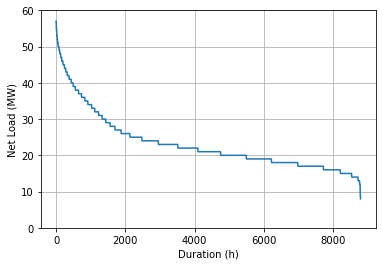

In [137]:
# Plot load duration curve
plt.plot(1 + np.arange(len(df)), df["MW Factor"].sort_values(ascending = False))
plt.grid()
plt.xlabel('Duration (h)')
plt.ylabel('Net Load (MW)')
plt.ylim(ymin=0, ymax=60)
#plt.xlim(xmin=0, xmax=8784)
plt.savefig('loadduration_23.svg', format='svg')

In [135]:
# N-1 Shortfall reduction as a function of storage size in the absence of current storage
y = np.arange(11)
xmax = 51
phi = np.zeros(len(y))
for i in y:
    phi[i] = sum(np.maximum(df["MW Factor"] - xmax - i, 0))

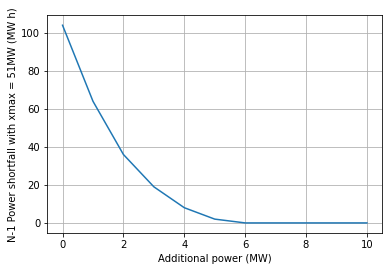

In [136]:
plt.plot(y, phi)
plt.grid()
plt.xlabel('Additional power (MW)')
plt.ylabel('N-1 Power shortfall with xmax = 51MW (MW h)')
plt.savefig('powershortfall_23.svg', format='svg')